In [36]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

load_dotenv()

True

In [37]:
model = ChatOpenAI(model="gpt-4o-mini")


class BlogState(TypedDict):
    topic: str
    detailed_outline: str
    detailed_blog:str

In [38]:
def blogOutline(state:BlogState)->BlogState:
    topic=state['topic']
    prompt=f"Generate outline for the topic {topic}"
    result=model.invoke(prompt).content
    state["detailed_outline"]=result
    return state

def detailedBlog(state:BlogState)->BlogState:
    topic=state["topic"]
    detailed_outline=state["detailed_outline"]
    prompt=f"Generate a detailed Blog on topic {topic} using the following outline\n {detailed_outline}"
    result=model.invoke(prompt).content
    state["detailed_blog"]=result
    return state

In [39]:
graph=StateGraph(BlogState)
graph.add_node("blogOutline",blogOutline)
graph.add_node("detailedBlog",detailedBlog)
graph.add_edge(START,"blogOutline")
graph.add_edge("blogOutline","detailedBlog")
graph.add_edge("blogOutline",END)
workflow=graph.compile()

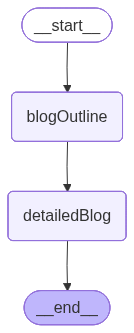

In [40]:
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
result=workflow.invoke({"topic":"Ai s boon or curse"})
print(result['detailed_outline'])
print(result['detailed_blog'])

### Outline for the Topic: "AI: A Boon or a Curse?"

#### I. Introduction
   A. Definition of Artificial Intelligence (AI)
   B. Overview of AI's rapid development and integration into society
   C. Purpose of the discussion: Examine both the positive and negative impacts of AI

#### II. The Benefits of AI (Boon)
   A. Advancements in healthcare
      1. Diagnosis and treatment personalization
      2. Drug discovery and development
      3. Telemedicine and patient monitoring
   B. Economic growth and efficiency
      1. Increased productivity and automation of tasks
      2. Creation of new job categories
      3. Cost reduction for businesses
   C. Innovations in daily life
      1. Smart home technologies
      2. Enhanced communication and connectivity
      3. Personal assistants and convenience features
   D. Environmental sustainability
      1. AI in climate modeling and resource management
      2. Optimization of energy consumption
      3. Innovations in recycling and waste